# Pedotransfer Functions

*Martin Vonk (2025)*

## Overview

Pedotransfer functions (PTFs) are empirical relationships that estimate soil hydraulic parameters from easily measured soil properties. They solve a practical problem: direct measurement of soil hydraulic properties is expensive and time-consuming, but soil particle size distribution and bulk density are relatively quick to measure.

`pedon` implements multiple pedotransfer functions from the literature, allowing you to estimate soil hydraulic parameters when:
- Particle size distribution (sand, silt, clay percentages) is known
- Bulk density and organic matter content are available
- Only limited data has been measured

This notebook demonstrates several PTF methods and shows how their predictions compare.

In [1]:
import pedon as pe

## Creating a Soil Sample

To use pedotransfer functions, we first create a `SoilSample` with measured soil properties. Let's use a typical loamy soil with moderate sand content.

In [2]:
# create soil sample
sand_p = 50  # sand [%]
silt_p = 20  # silt [%]
clay_p = 30  # clay [%]
rho = 1.5  # bulk density [g/cm3]
om_p = 10  # organic matter [%]
m50 = 150  # median sand fraction [um]
ts = False  # topsoil boolean

ss = pe.SoilSample(
    sand_p=sand_p, silt_p=silt_p, clay_p=clay_p, rho=rho, om_p=om_p, m50=m50
)

## Available Pedotransfer Functions

`pedon` provides several PTF options. Each has different input requirements and outputs. Apply one or more PTFs to see predictions.

In [3]:
# wosten pedotransfer function (van Genuchten)
wos = ss.wosten(ts=ts)

# wosten pedotransfer function for sand (van Genuchten)
woss = ss.wosten_sand(ts=ts)

# wosten pedotransfer function for clay (van Genuchten)
wosc = ss.wosten_clay()

# cosby pedotransfer function (Brook-Corey)
cosb = ss.cosby()

# rosetta database (options between version 1, 2 and 3)
ros = ss.rosetta(version=3)

Text(0.5, 0, '$K$ [cm/day]')

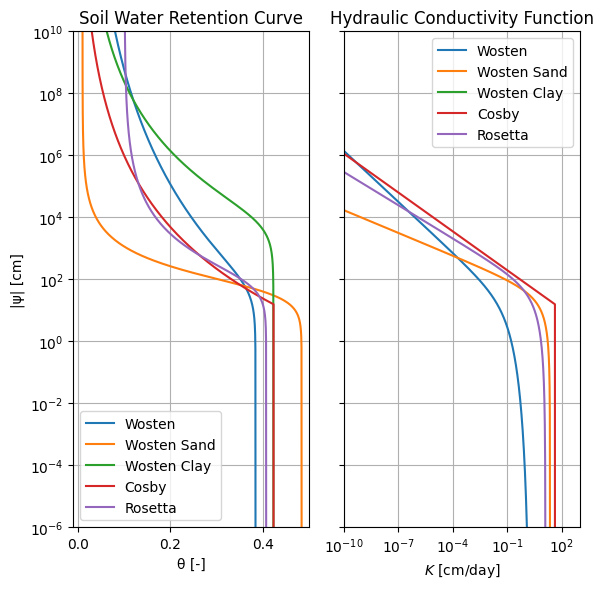

In [4]:
# More extensive plot method
axes = pe.plot.curves(wos, label="Wosten")
pe.plot.curves(woss, axes, label="Wosten Sand")
pe.plot.curves(wosc, axes, label="Wosten Clay")
pe.plot.curves(cosb, axes, label="Cosby")
pe.plot.curves(ros, axes, label="Rosetta")
axes[0].set_title("Soil Water Retention Curve")
axes[0].set_xlim(-0.01, 0.5)
axes[0].legend()
axes[0].set_xlabel(axes[0].get_xlabel() + " [-]")
axes[0].set_ylabel(axes[1].get_ylabel() + " [cm]")

axes[1].set_title("Hydraulic Conductivity Function")
axes[1].set_xlim(1e-10, 1e3)
axes[1].set_ylabel("")
axes[1].legend()
axes[1].set_xlabel(axes[1].get_xlabel() + " [cm/day]")

The plots above compare the predictions of different PTFs. Notice how different methods can give quite different results, particularly for the hydraulic conductivity function. This highlights the uncertainty inherent in PTFs and the importance of validating with measured data when possible.

## Next Steps

If you have measured data (water retention or conductivity values), proceed to the **Curve Fitting** notebook to refine these estimates. If you only have a single measurement (e.g., saturated conductivity), try the **HYPAGS** notebook for parameter estimation from limited data.